# Loading

## Necessities

In [1]:
# --- 1. Core Data Manipulation ---
import pandas as pd
import numpy as np

# --- 2. Data Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px  

# --- 3. Geospatial Analysis (The "Geophysics" Edge) ---
import folium  # For the interactive map
from folium.plugins import HeatMap, MarkerCluster
import geopandas as gpd 

# --- 4. Natural Language Processing (NLP) ---
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from wordcloud import WordCloud, STOPWORDS
# Download the VADER lexicon 
nltk.download('vader_lexicon')

# --- 5. Machine Learning ---
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

# The Heavy Hitters (Gradient Boosting)
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb 

# --- 6. Deployment (Streamlit)
import streamlit as st

# Configuration to make plots look nice
%matplotlib inline
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None) # Show all columns
import warnings
warnings.filterwarnings('ignore') # Silence annoying warnings

print("Libraries Imported Successfully..")

[nltk_data] Downloading package vader_lexicon to C:\Users\Hi-
[nltk_data]     Tech\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Libraries Imported Successfully..


## Data

In [2]:
df = pd.read_csv("D:\\Ahmed\\D.A\\Project\\Working\\Airbnb Investment Consultant\\listings.csv")
print("Data Loaded Successfully..")

Data Loaded Successfully..


In [3]:
df.head(2)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,13913,https://www.airbnb.com/rooms/13913,20250914034649,2025-09-16,city scrape,Holiday London DB Room Let-on going,My bright double bedroom with a large window h...,Finsbury Park is a friendly melting pot commun...,https://a0.muscache.com/pictures/miso/Hosting-...,54730,https://www.airbnb.com/users/show/54730,Alina,2009-11-16,"London, United Kingdom",I am a Multi-Media Visual Artist and Creative ...,within a few hours,100%,96%,t,https://a0.muscache.com/im/users/54730/profile...,https://a0.muscache.com/im/users/54730/profile...,LB of Islington,2.0,5.0,"['email', 'phone']",t,t,Neighborhood highlights,Islington,NaN,51.56861,-0.11270,Private room in rental unit,Private room,1,1.0,1 shared bath,1.0,1.0,"[""Self check-in"", ""Kitchen"", ""Smoke alarm"", ""D...",$70.00,1,29,1.0,1.0,29.0,29.0,1.0,29.0,NaN,t,21,39,69,331,2025-09-16,55,10,1,74,8,92,6440.0,2010-08-18,2025-08-21,4.85,4.80,4.80,4.81,4.87,4.78,4.78,NaN,f,2,1,1,0,0.30
1,15400,https://www.airbnb.com/rooms/15400,20250914034649,2025-09-16,city scrape,Bright Chelsea Apartment. Chelsea!,Lots of windows and light. St Luke's Gardens ...,It is Chelsea.,https://a0.muscache.com/pictures/428392/462d26...,60302,https://www.airbnb.com/users/show/60302,Philippa,2009-12-05,"Royal Borough of Kensington and Chelsea, Unite...","English, grandmother, I have travelled quite ...",NaN,NaN,50%,f,https://a0.muscache.com/im/users/60302/profile...,https://a0.muscache.com/im/users/60302/profile...,Chelsea,1.0,1.0,"['email', 'phone']",t,t,Neighborhood highlights,Kensington and Chelsea,NaN,51.48780,-0.16813,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Kitchen"", ""Smoke alarm"", ""Dedicated workspac...",$149.00,4,30,4.0,4.0,30.0,30.0,4.0,30.0,NaN,t,0,0,0,199,2025-09-16,97,1,0,0,2,9,1341.0,2009-12-21,2025-04-05,4.80,4.86,4.87,4.88,4.84,4.93,4.74,NaN,f,1,1,0,0,0.51


# Data Cleaning

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96871 entries, 0 to 96870
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            96871 non-null  int64  
 1   listing_url                                   96871 non-null  object 
 2   scrape_id                                     96871 non-null  int64  
 3   last_scraped                                  96871 non-null  object 
 4   source                                        96871 non-null  object 
 5   name                                          96871 non-null  object 
 6   description                                   94421 non-null  object 
 7   neighborhood_overview                         41208 non-null  object 
 8   picture_url                                   96865 non-null  object 
 9   host_id                                       96871 non-null 

In [5]:
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0].sort_values(ascending=False))

calendar_updated                96871
license                         96871
neighbourhood_group_cleansed    96871
neighborhood_overview           55663
neighbourhood                   55662
host_neighbourhood              51021
host_about                      47038
beds                            34920
estimated_revenue_l365d         34908
price                           34908
bathrooms                       34846
host_response_time              31707
host_response_rate              31707
host_acceptance_rate            27760
review_scores_value             24166
review_scores_location          24166
review_scores_checkin           24165
review_scores_communication     24142
review_scores_accuracy          24137
review_scores_cleanliness       24131
reviews_per_month               24122
review_scores_rating            24122
last_review                     24122
first_review                    24122
host_location                   23771
bedrooms                        12775
has_availabi

## Structure & Formatting

In [6]:
cols_to_drop = [
    'listing_url', 'scrape_id', 'last_scraped', 'source', 'picture_url', 
    'host_url', 'host_thumbnail_url', 'host_picture_url', 
    'neighbourhood_group_cleansed', 'calendar_updated', 'license',
    'bathrooms'
]
df_clean = df.drop(columns=cols_to_drop, errors='ignore')


In [7]:
# A. Fix Price (Remove '$' and ',')
df_clean['price'] = df_clean['price'].astype(str).str.replace('$', '').str.replace(',', '')
df_clean['price'] = pd.to_numeric(df_clean['price'], errors='coerce')

# B. Fix Dates
date_cols = ['host_since', 'first_review', 'last_review']
for col in date_cols:
    df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')

print(f"New Shape: {df_clean.shape}")
print(df_clean[['price', 'host_since']].dtypes)

New Shape: (96871, 67)
price                float64
host_since    datetime64[ns]
dtype: object


## The "Bathroom" Trap

In [8]:
# Function to extract number from text
import re

def extract_bathrooms(text):
    if pd.isna(text):
        return np.nan
    text = str(text).lower()
    if 'half-bath' in text:
        return 0.5
    match = re.search(r"(\d+(\.\d+)?)", text)
    if match:
        return float(match.group(1))
    return np.nan

# Apply logic
df_clean['bathrooms_cleaned'] = df_clean['bathrooms_text'].apply(extract_bathrooms)

# Drop the old text column now that we have the number
df_clean.drop(columns=['bathrooms_text'], inplace=True)

# Check results
print(df_clean[['bathrooms_cleaned']].describe())

       bathrooms_cleaned
count       96718.000000
mean            1.330512
std             0.678965
min             0.000000
25%             1.000000
50%             1.000000
75%             1.500000
max            30.000000


## Missing Values

In [9]:
# 1. Fill Bedrooms/Beds with Median
for col in ['bedrooms', 'beds']:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

In [10]:
# If no reviews, we fill with the average, but we flag it so the model knows.
review_cols = [col for col in df_clean.columns if 'review_scores' in col]

for col in review_cols:
    df_clean[col].fillna(df_clean[col].mean(), inplace=True)

In [11]:
# 3. Drop rows where we have NO Host info or NO Price (Crucial)
df_clean.dropna(subset=['host_since', 'price'], inplace=True)

In [12]:
# Check our work
print(f"Missing values remaining in Price: {df_clean['price'].isnull().sum()}")
print(f"Missing values remaining in Bedrooms: {df_clean['bedrooms'].isnull().sum()}")

Missing values remaining in Price: 0
Missing values remaining in Bedrooms: 0


## Outliers

In [13]:
# 1. Price Logic
upper_limit = df_clean['price'].quantile(0.99)
df_clean = df_clean[(df_clean['price'] > 10) & (df_clean['price'] < upper_limit)]


In [14]:
# 2. Minimum Nights Logic
df_clean = df_clean[df_clean['minimum_nights'] < 365]

print(f"Final Cleaned Dataset Shape: {df_clean.shape}")


Final Cleaned Dataset Shape: (61276, 67)


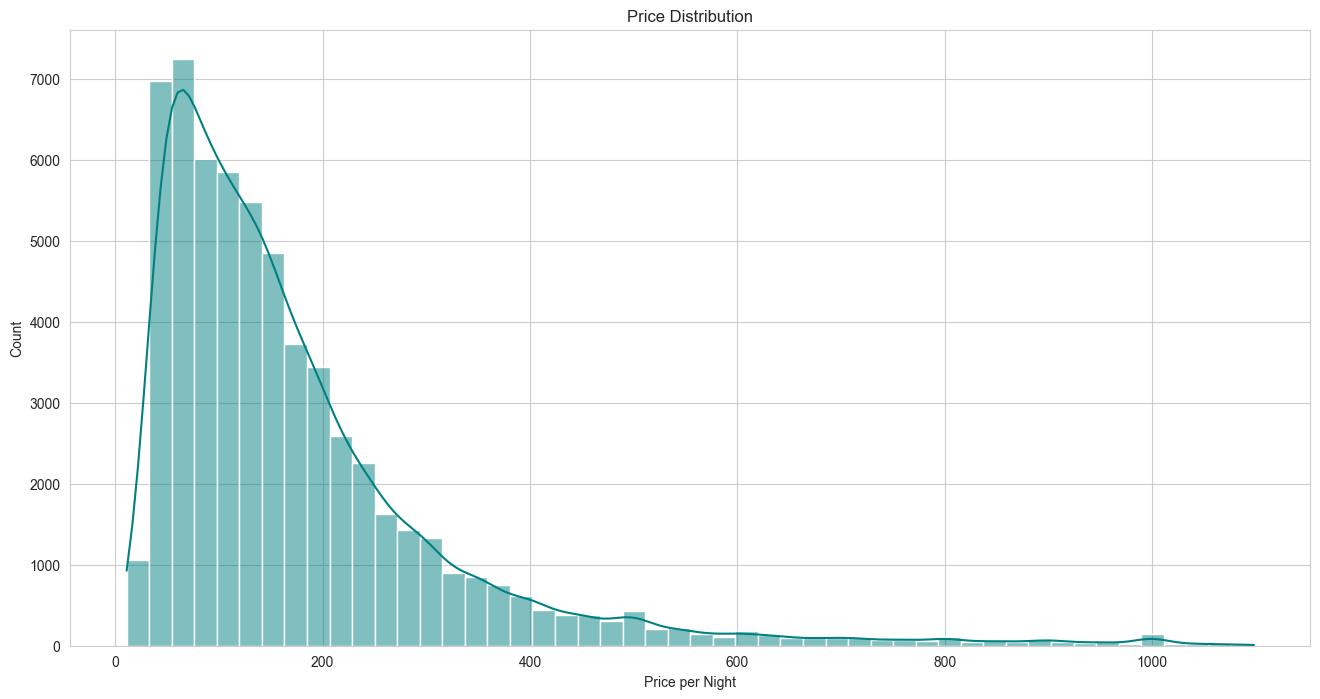

In [15]:
# Visualization: Let's see the clean Price Distribution
plt.figure(figsize=(16, 8))
sns.histplot(df_clean['price'], bins=50, kde=True, color='teal')
plt.title('Price Distribution')
plt.xlabel('Price per Night')
plt.show()

****

# Exploratory Spatial Analysis

In [16]:
df_clean.head(1)

,id,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,bathrooms_cleaned
0,13913,Holiday London DB Room Let-on going,My bright double bedroom with a large window h...,Finsbury Park is a friendly melting pot commun...,54730,Alina,2009-11-16,"London, United Kingdom",I am a Multi-Media Visual Artist and Creative ...,within a few hours,100%,96%,t,LB of Islington,2.0,5.0,"['email', 'phone']",t,t,Neighborhood highlights,Islington,51.56861,-0.1127,Private room in rental unit,Private room,1,1.0,1.0,"[""Self check-in"", ""Kitchen"", ""Smoke alarm"", ""D...",70.0,1,29,1.0,1.0,29.0,29.0,1.0,29.0,t,21,39,69,331,2025-09-16,55,10,1,74,8,92,6440.0,2010-08-18,2025-08-21,4.85,4.8,4.8,4.81,4.87,4.78,4.78,f,2,1,1,0,0.3,1.0


In [17]:
from IPython.display import display, HTML

In [18]:
london_lat =  51.507
london_lon = -0.1276
map_london = folium.Map(location=[london_lat, london_lon], zoom_start=12)
heat_data = df_clean[['latitude', 'longitude']].values
HeatMap(heat_data, radius=10, blur=15, gradient={0.4: 'blue', 0.65: 'lime', 1: 'red'}).add_to(map_london)

marker_cluster = MarkerCluster().add_to(map_london)

for idx, row in df_clean.sample(1000).iterrows():
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=f"${row['price']} - {row['room_type']}",
        icon=folium.Icon(color='green' if row['price'] < 150 else 'red', icon='home')
        
    ).add_to(marker_cluster)

In [19]:
map_london

In [20]:
def haversine_function(lat1, lon1, lat2, lon2):
    """_summary_

    Args:
        lat1 (float): Latitude of the first point in degrees.
        lon1 (float): Longitude of the first point in degrees.
        lat2 (float): Latitude of the second point in degrees.
        lon2 (float): Longitude of the second point in degrees.

    Returns:
        float: The distance between the two points in kilometers.
    """
    # Radius of Earth in kilometers
    earth_radius_km = 6371
    
    # differences
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    
    # convert to radians
    lat1 = np.radians(lat1)
    lat2 = np.radians(lat2)
    
    #  intermediate value
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    
    # the central angle
    c = 2 * np.arcsin(np.sqrt(a))
    
    #  distance
    d = earth_radius_km * c
    
    return d
    

In [21]:
df_clean['distance_to_center'] = haversine_function(
    df_clean['latitude'], 
    df_clean['longitude'], 
    london_lat, 
    london_lon
)

Text(0.5, 1.0, 'Price vs. Distance to City Center')

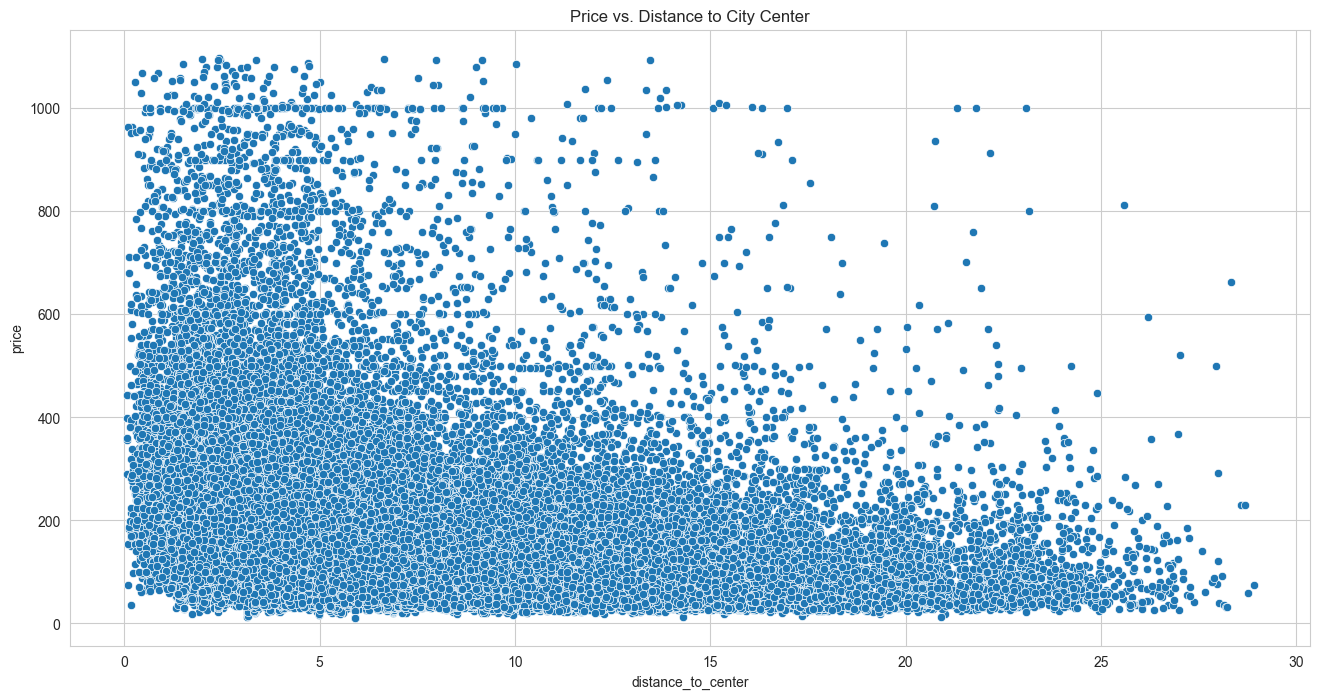

In [22]:
plt.figure(figsize=(16, 8))
sns.scatterplot(data=df_clean, x='distance_to_center', y='price')
plt.title('Price vs. Distance to City Center')

**This confirms that location is a primary driver of value. A property 20km away rarely commands the same premium as one in the center, regardless of its amenities**

****

# NLP & Sentiment Analysis.

In [23]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

# Test it out to see how it thinks
text_example = "The apartment was beautiful but the host was rude."
score = sia.polarity_scores(text_example)
print(score)

{'neg': 0.297, 'neu': 0.52, 'pos': 0.182, 'compound': -0.3716}


In [24]:
reviews_df = pd.read_csv("D:\\Ahmed\\D.A\\Project\\Working\\Airbnb Investment Consultant\\reviews.csv")
reviews_df.head(2)

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,13913,80770,2010-08-18,177109,Michael,My girlfriend and I hadn't known Alina before ...
1,13913,367568,2011-07-11,19835707,Mathias,Alina was a really good host. The flat is clea...


In [25]:
reviews_df.isna().sum()

listing_id         0
id                 0
date               0
reviewer_id        0
reviewer_name      2
comments         201
dtype: int64

In [26]:
reviews_df.dropna(subset=['comments'], inplace=True)

In [27]:
reviews_df.shape

(2097795, 6)

In [28]:
reviews_sample = reviews_df.sample(50000).copy()
reviews_sample['sentiment_score'] = reviews_sample['comments'].apply(lambda x: sia.polarity_scores(x)['compound'])
reviews_sample.head(2)

,listing_id,id,date,reviewer_id,reviewer_name,comments,sentiment_score
1857128,1112273597826621116,1397034213515721812,2025-04-11,2000116,Reem,we came with 2 children.. the location was gre...,0.9260
1589842,848397653907883940,987612357130424730,2023-09-24,152341839,Ashley,I was so impressed with this stay! Everything ...,0.9615


In [29]:
listing_ids_with_sentiment = reviews_sample[['listing_id', 'sentiment_score']].groupby('listing_id').mean().reset_index()
listing_ids_with_sentiment.head(2)

,listing_id,sentiment_score
0,13913,0.955900
1,15400,0.803033


In [30]:
df_final = df_clean.merge(listing_ids_with_sentiment, left_on='id', right_on='listing_id', how='left')
df_final['sentiment_score'].fillna(0, inplace=True)
df_final.drop(columns=['listing_id'], inplace=True)

In [31]:
df_final.sample(2)

,id,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,bathrooms_cleaned,distance_to_center,sentiment_score
9409,37704525,Nice 3 bed warehouse apartment in Chiswick/London,"This warehouse style apartment is beautiful, w...","Near the popular Chiswick High Road, which off...",29211630,Eli,2015-03-12,"London, United Kingdom",Passionate about higher standard properties an...,within an hour,100%,100%,f,Chiswick,22.0,33.0,"['email', 'phone']",t,t,Neighborhood highlights,Hounslow,51.494480,-0.279240,Entire rental unit,Entire home/apt,8,3.0,3.0,"[""Self check-in"", ""Kitchen"", ""Smoke alarm"", ""S...",225.0,10,1125,1.0,10.0,1125.0,1125.0,5.8,1125.0,t,9,39,65,161,2025-09-15,105,26,2,74,20,255,57375.0,2019-10-11,2025-09-01,4.59,4.66,4.68,4.74,4.73,4.51,4.53,f,21,21,0,0,1.45,2.0,10.588340,0.6946
31225,1083471379509890152,30 min tube to Oxford Street /BH,Bring the whole family or group to this stylis...,NaN,185324181,Jonathan Stanley,2018-04-20,"England, United Kingdom",NaN,within an hour,95%,99%,f,Harringay Ladder,140.0,213.0,"['email', 'phone']",t,t,NaN,Redbridge,51.580381,0.057425,Entire home,Entire home/apt,16,5.0,11.0,"[""Kitchen"", ""Smoke alarm"", ""Free driveway park...",196.0,4,365,4.0,4.0,365.0,365.0,4.0,365.0,t,15,38,64,308,2025-09-14,31,18,0,77,19,166,32536.0,2024-03-13,2025-07-17,4.42,4.45,4.13,4.48,4.39,4.55,4.52,t,138,135,3,0,1.69,3.0,15.175544,0.0000


In [32]:
print(f"Sentiment Analysis Complete. Final Shape: {df_final.shape}")
print(df_final[['price', 'sentiment_score']].head())

Sentiment Analysis Complete. Final Shape: (61276, 69)
   price  sentiment_score
0   70.0         0.955900
1  149.0         0.803033
2  411.0         0.678850
3  210.0         0.000000
4  280.0         0.905560


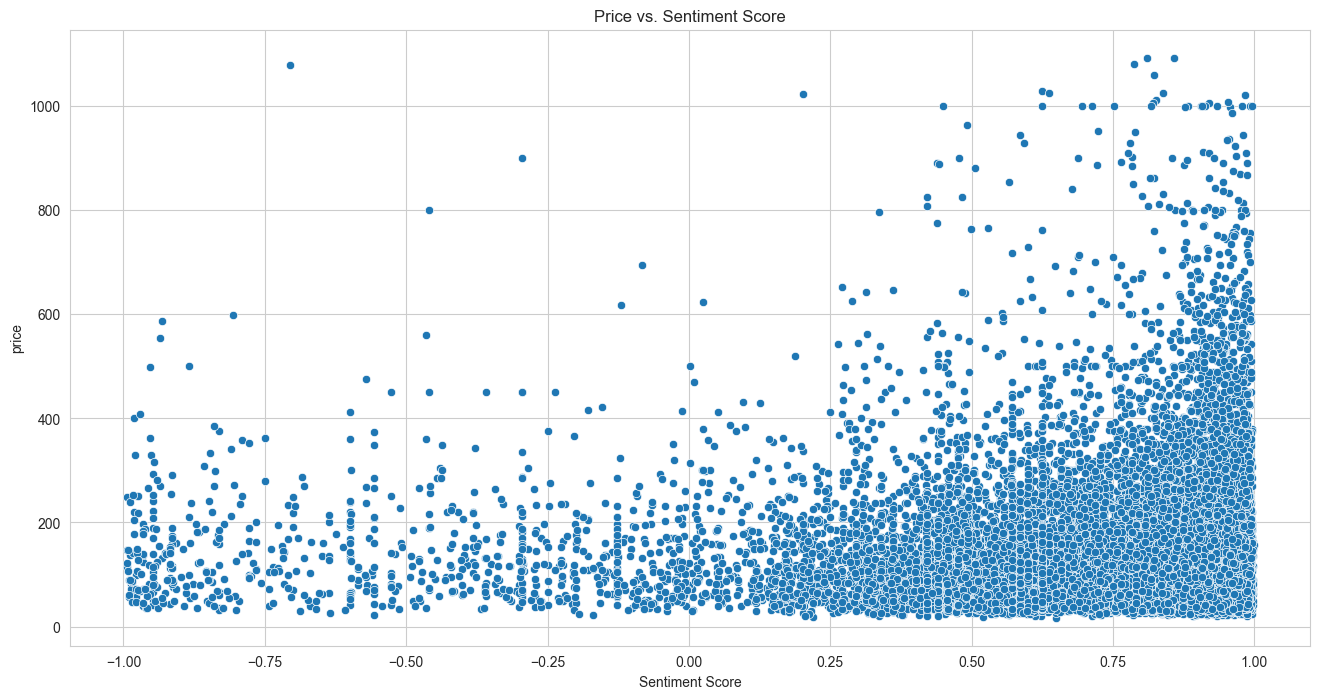

In [33]:
plt.figure(figsize=(16, 8))
sns.scatterplot(data=df_final[df_final['sentiment_score'] != 0], x='sentiment_score', y='price')
plt.title('Price vs. Sentiment Score')
plt.xlabel('Sentiment Score')
plt.show()

****

# Machine Learning

## Preprocessing

In [34]:
ml_df = pd.get_dummies(df_final, columns=['room_type', 'neighbourhood_cleansed'], drop_first=True, dtype=int)
ml_df.shape

(61276, 102)

In [35]:
ml_df.head(2)

,id,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,latitude,longitude,property_type,accommodates,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,bathrooms_cleaned,distance_to_center,sentiment_score,room_type_Hotel room,room_type_Private room,room_type_Shared room,neighbourhood_cleansed_Barnet,neighbourhood_cleansed_Bexley,neighbourhood_cleansed_Brent,neighbourhood_cleansed_Bromley,neighbourhood_cleansed_Camden,neighbourhood_cleansed_City of London,neighbourhood_cleansed_Croydon,neighbourhood_cleansed_Ealing,neighbourhood_cleansed_Enfield,neighbourhood_cleansed_Greenwich,neighbourhood_cleansed_Hackney,neighbourhood_cleansed_Hammersmith and Fulham,neighbourhood_cleansed_Haringey,neighbourhood_cleansed_Harrow,neighbourhood_cleansed_Havering,neighbourhood_cleansed_Hillingdon,neighbourhood_cleansed_Hounslow,neighbourhood_cleansed_Islington,neighbourhood_cleansed_Kensington and Chelsea,neighbourhood_cleansed_Kingston upon Thames,neighbourhood_cleansed_Lambeth,neighbourhood_cleansed_Lewisham,neighbourhood_cleansed_Merton,neighbourhood_cleansed_Newham,neighbourhood_cleansed_Redbridge,neighbourhood_cleansed_Richmond upon Thames,neighbourhood_cleansed_Southwark,neighbourhood_cleansed_Sutton,neighbourhood_cleansed_Tower Hamlets,neighbourhood_cleansed_Waltham Forest,neighbourhood_cleansed_Wandsworth,neighbourhood_cleansed_Westminster
0,13913,Holiday London DB Room Let-on going,My bright double bedroom with a large window h...,Finsbury Park is a friendly melting pot commun...,54730,Alina,2009-11-16,"London, United Kingdom",I am a Multi-Media Visual Artist and Creative ...,within a few hours,100%,96%,t,LB of Islington,2.0,5.0,"['email', 'phone']",t,t,Neighborhood highlights,51.56861,-0.11270,Private room in rental unit,1,1.0,1.0,"[""Self check-in"", ""Kitchen"", ""Smoke alarm"", ""D...",70.0,1,29,1.0,1.0,29.0,29.0,1.0,29.0,t,21,39,69,331,2025-09-16,55,10,1,74,8,92,6440.0,2010-08-18,2025-08-21,4.85,4.80,4.80,4.81,4.87,4.78,4.78,f,2,1,1,0,0.30,1.0,6.927795,0.955900,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,15400,Bright Chelsea Apartment. Chelsea!,Lots of windows and light. St Luke's Gardens ...,It is Chelsea.,60302,Philippa,2009-12-05,"Royal Borough of Kensington and Chelsea, Unite...","English, grandmother, I have travelled quite ...",NaN,NaN,50%,f,Chelsea,1.0,1.0,"['email', 'phone']",t,t,Neighborhood highlights,51.48780,-0.16813,Entire rental unit,2,1.0,1.0,"[""Kitchen"", ""Smoke alarm"", ""Dedicated workspac...",149.0,4,30,4.0,4.0,30.0,30.0,4.0,30.0,t,0,0,0,199,2025-09-16,97,1,0,0,2,9,1341.0,2009-12-21,2025-04-05,4.80,4.86,4.87,4.88,4.84,4.93,4.74,f,1,1,0,0,0.51,1.0,3.525584,0.803033,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


## Training

### Data

In [36]:
# Prepare Data for ML
cols_to_drop = ['price', 'property_type', 'name', 'description', 'amenities']
X= ml_df.drop(columns=cols_to_drop, errors='ignore')

In [37]:
# Keep only numeric columns 
X=X.select_dtypes(include=[np.number])  # Keep only numeric columns
y= ml_df['price']

In [38]:
print(f"Features (X) Shape: {X.shape}")
print(f"Target (y) Shape: {y.shape}")

Features (X) Shape: (61276, 78)
Target (y) Shape: (61276,)


In [39]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Model

In [40]:
# Building the XGBoost Model
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=1000, 
    learning_rate=0.05, 
    max_depth=7, 
    random_state=42,
    n_jobs=-1)

In [41]:
# Training the model
xgb_model.fit(
    X_train, y_train, 
    eval_set=[(X_test, y_test)], 
    verbose=False
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [42]:
# Predictions
y_pred = xgb_model.predict(X_test)

In [43]:
# Evaluation
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("------------------------------------------------")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"R² Score (Accuracy): {r2:.2f}")
print("------------------------------------------------")

------------------------------------------------
Mean Absolute Error (MAE): $28.51
R² Score (Accuracy): 0.82
------------------------------------------------


****

# Business Intelligence

## Feature Importance

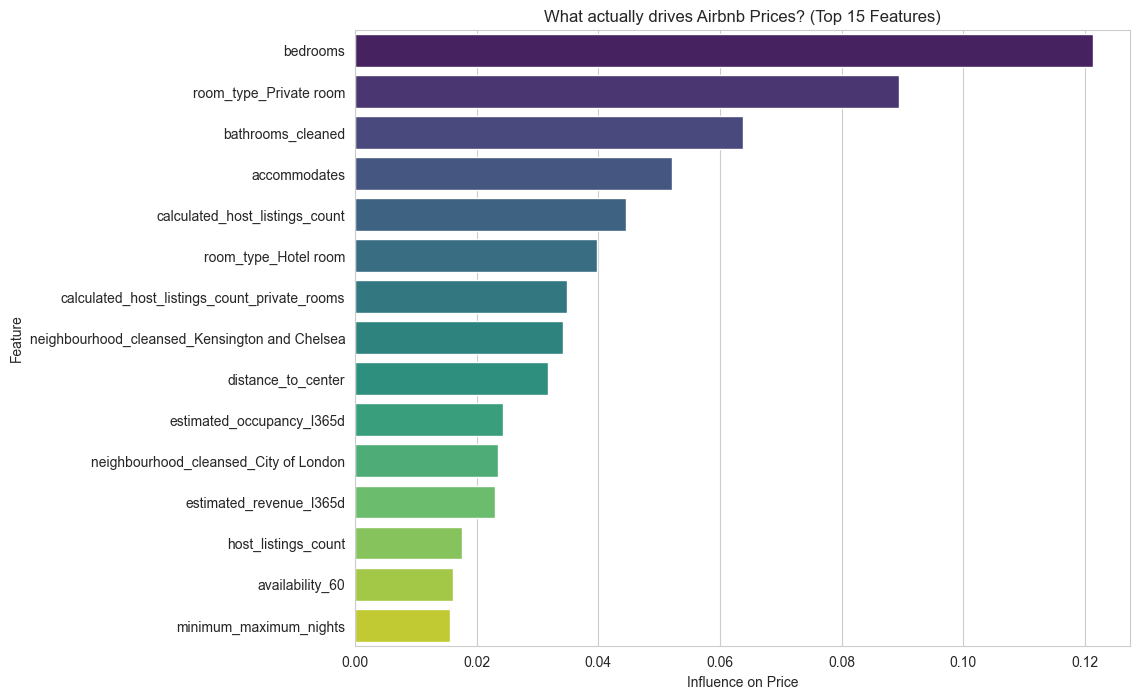

In [44]:

importance = xgb_model.feature_importances_
feature_names = X_train.columns

feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
feat_df = feat_df.sort_values(by='Importance', ascending=False).head(15) # Top 15

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')
plt.title('What actually drives Airbnb Prices? (Top 15 Features)')
plt.xlabel('Influence on Price')
plt.show()

- **Space is King (bedrooms)**: The #1 driver of price is simply size. This makes sense, a 3-bedroom house will always cost more than a 1-bedroom, regardless of where it is.

- **Privacy Matters (room_type_Private room)**: This is the #2 factor. The negative impact of sharing a room (or the positive impact of having the whole place) is massive.

- **Location is Specific (Kensington and Chelsea)**: distance_to_center is important (Rank #9), but living in a specific luxury neighborhood like "Kensington and Chelsea" (Rank #7) is even more powerful. This is a great nuance: "General proximity is good, but brand-name neighborhoods are better."

## Investment Recommendation

In [45]:
# 1. Create a DataFrame of the Test Set
results = X_test.copy()
results['Actual_Price'] = y_test
results['Predicted_Price'] = xgb_model.predict(X_test)

# 2. Calculate the "Discount"
results['Potential_Profit_Per_Night'] = results['Predicted_Price'] - results['Actual_Price']

# 3. Filter: We only want properties that are ALREADY cheap (<$150) but have high potential
gems = results[results['Actual_Price'] < 150].sort_values(by='Potential_Profit_Per_Night', ascending=False).head(5)

# 4. Display the "Gold List"
cols_to_show = ['Actual_Price', 'Predicted_Price', 'Potential_Profit_Per_Night', 'bedrooms', 'distance_to_center']
print("--- TOP 5 INVESTMENT OPPORTUNITIES ---")
print(gems[cols_to_show])

--- TOP 5 INVESTMENT OPPORTUNITIES ---
       Actual_Price  Predicted_Price  Potential_Profit_Per_Night  bedrooms  \
56545          52.0       789.953674                  737.953674       1.0   
56567          68.0       789.953674                  721.953674       1.0   
56189          59.0       727.677185                  668.677185       1.0   
56547         100.0       698.810242                  598.810242       1.0   
56435          63.0       617.434998                  554.434998       1.0   

       distance_to_center  
56545            5.351150  
56567            5.353141  
56189            3.595565  
56547            2.851753  
56435            4.551596  


****

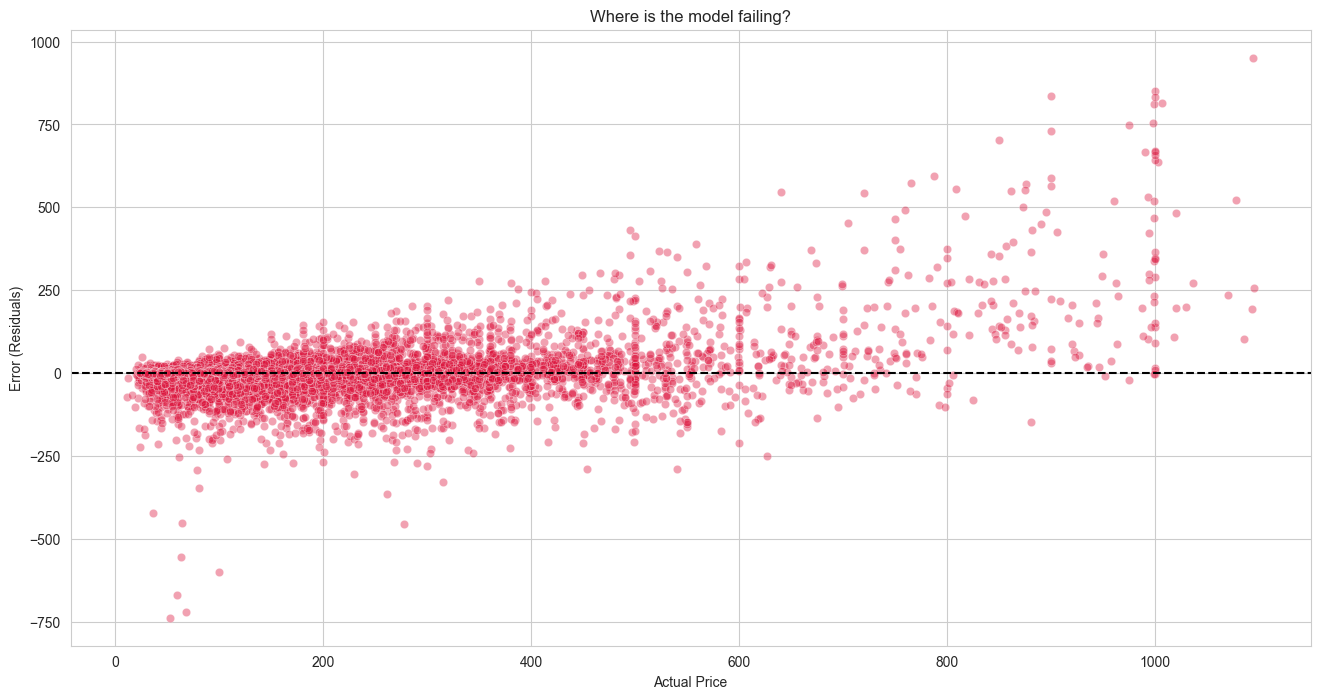

In [46]:
# Residual Plot
plt.figure(figsize=(16, 8))
sns.scatterplot(x=y_test, y=y_test - y_pred, alpha=0.4, color='crimson')
plt.axhline(0, color='black', linestyle='--') # The "Perfect Prediction" line
plt.xlabel('Actual Price')
plt.ylabel('Error (Residuals)')
plt.title('Where is the model failing?')
plt.show()

****

In [47]:

xgb_model.save_model("xgb_model.json")


In [48]:
map_cols = ['latitude', 'longitude', 'price', 'room_type']
df_clean[map_cols].to_csv("app_data.csv", index=False)

print("Files ready for deployment!")

Files ready for deployment!


In [53]:
df_clean.shape

(61276, 68)

In [49]:
df_clean.to_parquet("app_data.parquet")

In [55]:
import joblib

# Save the exact order of columns the model expects
# This file is tiny (1KB)
joblib.dump(X_train.columns, 'model_columns.joblib')

print("Column names saved!")

Column names saved!
